In [4]:
# Cell 1: Import Libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 6)


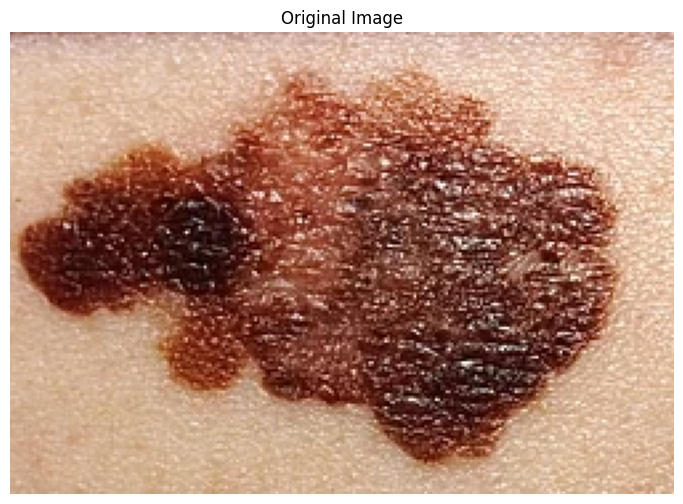

In [5]:
# Cell 2: Load Image

image_path = r"D:\Final Year Project\ImageProcessing\Images\Melanoma_1.jpg"  
img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()


In [6]:
# Cell 3: Compute Laplacian Variance (Sharpness)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale for sharpness check
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
lap_var = laplacian.var()

print("Laplacian Variance (Image Sharpness):", lap_var)

# Optional: set a threshold to flag blurry images
sharp_threshold = 100  # you can adjust this experimentally
if lap_var < sharp_threshold:
    print("Warning: Image may be blurry!")
else:
    print("Image appears sharp.")


Laplacian Variance (Image Sharpness): 8223.56631429198
Image appears sharp.


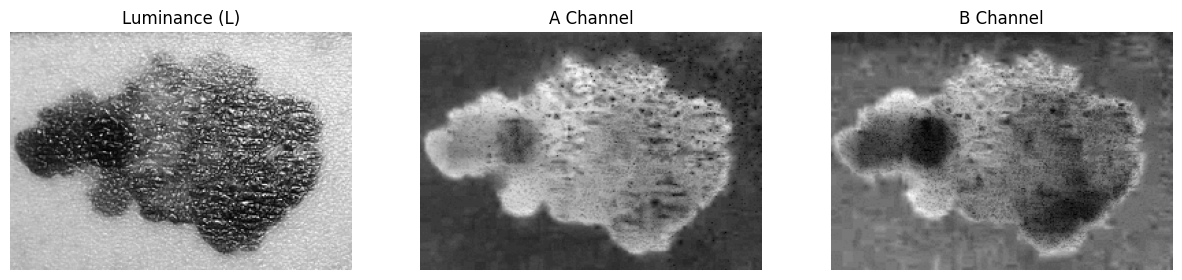

In [8]:
# Cell 4: Convert to LAB color space

lab_img = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab_img)

# Display L, A, B channels for reference
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(L, cmap='gray')
plt.title("Luminance (L)")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(A, cmap='gray')
plt.title("A Channel")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(B, cmap='gray')
plt.title("B Channel")
plt.axis('off')
plt.show()


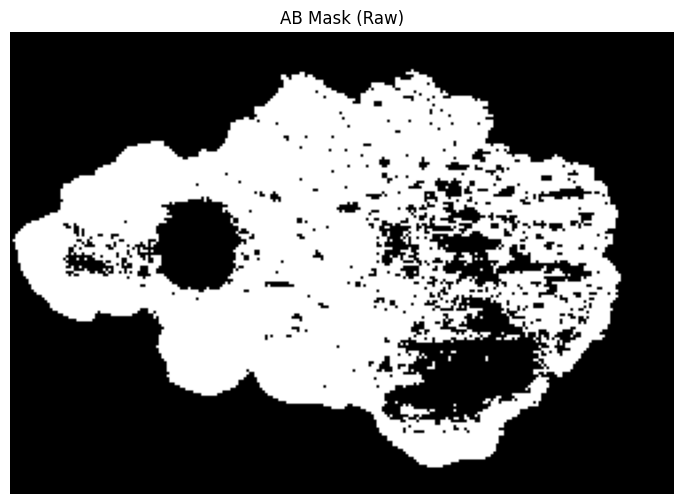

In [9]:
# Cell 4: AB clustering to generate lesion mask

ab = np.stack([A, B], axis=2)
ab_flat = ab.reshape((-1, 2))
ab_flat = np.float32(ab_flat)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
K = 2  # Two clusters: lesion vs skin
_, labels, centers = cv2.kmeans(ab_flat, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
labels = labels.flatten().reshape(A.shape)

# Identify lesion cluster as the one with darker L values
cluster_means = [np.mean(L[labels == i]) for i in range(K)]
lesion_cluster = np.argmin(cluster_means)
AB_mask = np.uint8(labels == lesion_cluster) * 255

plt.imshow(AB_mask, cmap='gray')
plt.title("AB Mask (Raw)")
plt.axis('off')
plt.show()


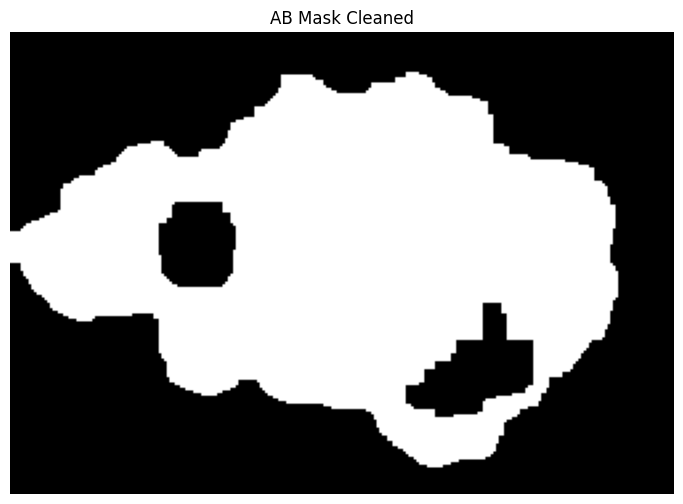

In [10]:
# Cell 5: Morphological cleanup

kernel_close = np.ones((7,7), np.uint8)
kernel_open = np.ones((5,5), np.uint8)

AB_mask_clean = cv2.morphologyEx(AB_mask, cv2.MORPH_CLOSE, kernel_close)
AB_mask_clean = cv2.morphologyEx(AB_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(AB_mask_clean, cmap='gray')
plt.title("AB Mask Cleaned")
plt.axis('off')
plt.show()


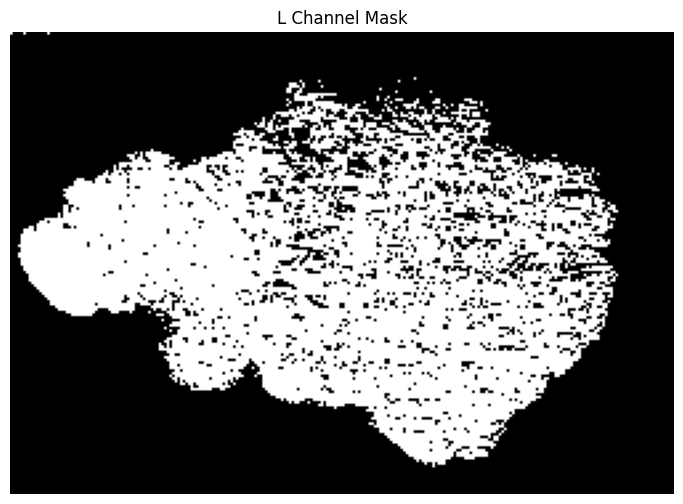

In [12]:
# L-channel mask 
L_norm = cv2.normalize(L, None, 0, 255, cv2.NORM_MINMAX)

# Use Otsu threshold (inverse so lesion is white)
_, L_mask = cv2.threshold(L_norm, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

plt.imshow(L_mask, cmap='gray')
plt.title("L Channel Mask")
plt.axis('off')
plt.show()


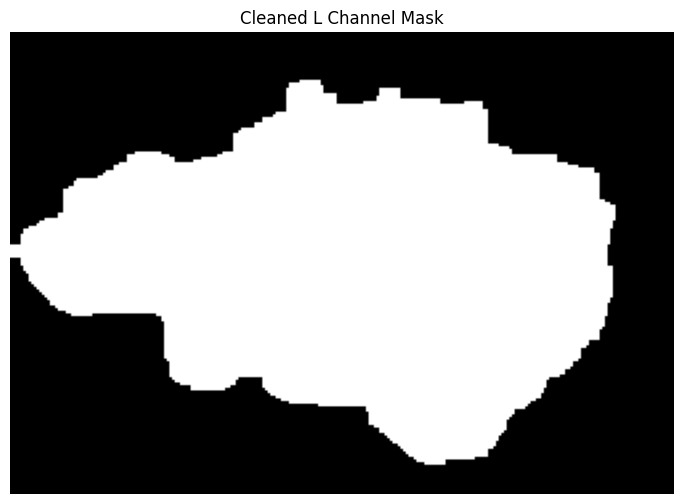

In [13]:
kernel_close = np.ones((7,7), np.uint8)
kernel_open = np.ones((5,5), np.uint8)

L_mask_clean = cv2.morphologyEx(L_mask, cv2.MORPH_CLOSE, kernel_close)
L_mask_clean = cv2.morphologyEx(L_mask_clean, cv2.MORPH_OPEN, kernel_open)

plt.imshow(L_mask_clean, cmap='gray')
plt.title("Cleaned L Channel Mask")
plt.axis('off')
plt.show()


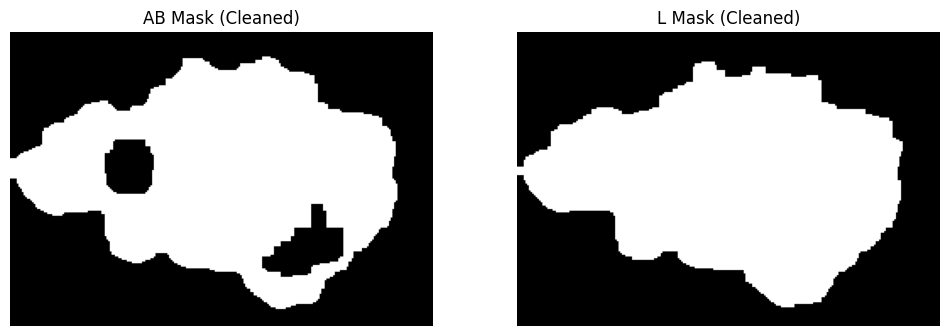

In [14]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(AB_mask_clean, cmap='gray')
plt.title("AB Mask (Cleaned)")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(L_mask_clean, cmap='gray')
plt.title("L Mask (Cleaned)")
plt.axis('off')
plt.show()


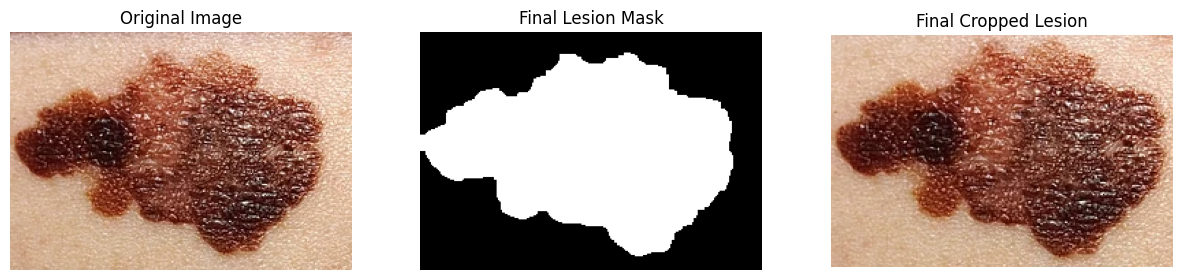

In [15]:
# Cell 6: Optional tight crop of lesion from mask
contours, _ = cv2.findContours(AB_mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
if len(contours) > 0:
    largest_contour = max(contours, key=cv2.contourArea)
    lesion_mask_final = np.zeros_like(AB_mask_clean)
    cv2.drawContours(lesion_mask_final, [largest_contour], -1, 255, -1)

    x, y, w_box, h_box = cv2.boundingRect(largest_contour)
    pad = 5
    x1 = max(x - pad, 0)
    y1 = max(y - pad, 0)
    x2 = min(x + w_box + pad, AB_mask_clean.shape[1])
    y2 = min(y + h_box + pad, AB_mask_clean.shape[0])

    lesion_crop_final = img[y1:y2, x1:x2]

    plt.figure(figsize=(15,5))
    plt.subplot(1,3,1)
    plt.imshow(img_rgb)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(lesion_mask_final, cmap='gray')
    plt.title("Final Lesion Mask")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(lesion_crop_final, cv2.COLOR_BGR2RGB))
    plt.title("Final Cropped Lesion")
    plt.axis('off')
    plt.show()


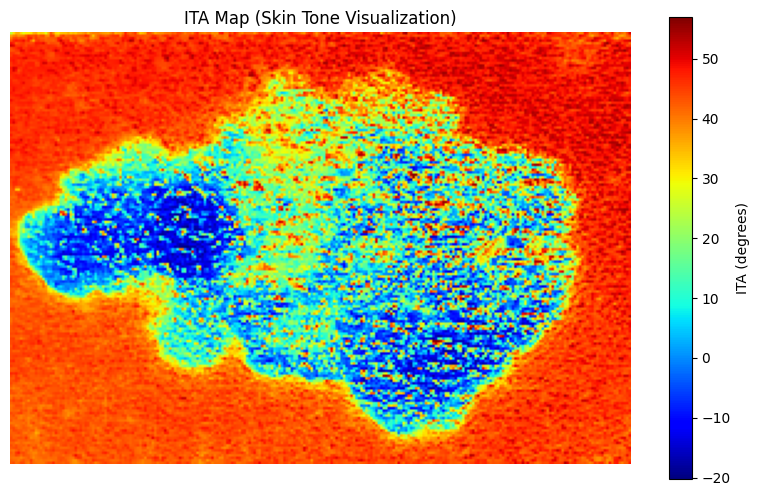

In [17]:
# Cell 7: ITA map (skin tone visualization)

L_float = L.astype(np.float32)
B_float = B.astype(np.float32)
ITA = np.arctan2((L_float - 50), B_float) * (180 / np.pi)

plt.imshow(ITA, cmap='jet')
plt.colorbar(label='ITA (degrees)')
plt.title("ITA Map (Skin Tone Visualization)")
plt.axis('off')
plt.show()


In [19]:
# Cell 8: Resize & Normalize for ML Model

if len(contours) > 0:
    lesion_resized = cv2.resize(lesion_crop, (224, 224))
    lesion_normalized = lesion_resized / 255.0
    print("Lesion ready for model input:", lesion_normalized.shape)


Lesion ready for model input: (224, 224, 3)
